# Decision trees

In [1]:
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import root_mean_squared_error

In [2]:
df = pd.read_csv('data/car_fuel_efficiency.csv')

## Data preparation and EDA

In [3]:
df.head().T

,0,1,2,3,4
engine_displacement,170,130,170,220,210
num_cylinders,3.0,5.0,NaN,4.0,1.0
horsepower,159.0,97.0,78.0,NaN,140.0
vehicle_weight,3413.433759,3149.664934,3079.038997,2542.392402,3460.87099
acceleration,17.7,17.8,15.1,20.2,14.4
model_year,2003,2007,2018,2009,2009
origin,Europe,USA,Europe,USA,Europe
fuel_type,Gasoline,Gasoline,Gasoline,Diesel,Gasoline
drivetrain,All-wheel drive,Front-wheel drive,Front-wheel drive,All-wheel drive,All-wheel drive
num_doors,0.0,0.0,0.0,2.0,2.0


In [4]:
cat_cols = df.select_dtypes(include='object').columns

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_') # replacing spaces with underscore and chanhing column names to lower case
df.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='object')

In [6]:
for c in cat_cols:
        df[c] = df[c].str.lower().str.replace(' ', '_')

In [7]:
df.isna().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [8]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

## Setting up the validation framework¶

In [11]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [12]:
len(df_train), len(df_val), len(df_test)

(5822, 1941, 1941)

In [13]:
df.describe().round()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,num_doors,fuel_efficiency_mpg
count,9704.0,9222.0,8996.0,9704.0,8774.0,9704.0,9202.0,9704.0
mean,200.0,4.0,150.0,3001.0,15.0,2011.0,-0.0,15.0
std,49.0,2.0,30.0,498.0,3.0,7.0,1.0,3.0
min,10.0,0.0,37.0,953.0,6.0,2000.0,-4.0,6.0
25%,170.0,3.0,130.0,2666.0,13.0,2006.0,-1.0,13.0
50%,200.0,4.0,149.0,2993.0,15.0,2012.0,0.0,15.0
75%,230.0,5.0,170.0,3335.0,17.0,2017.0,1.0,17.0
max,380.0,13.0,271.0,4739.0,24.0,2023.0,4.0,26.0


In [14]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [15]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [16]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']


## One-hot encoding

In [17]:
dv = DictVectorizer(sparse=True)

In [18]:
train_dict = df_train.fillna(0).to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

In [19]:
val_dict = df_val.fillna(0).to_dict(orient='records')
X_val = dv.fit_transform(val_dict)

In [20]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 58220 stored elements and shape (5822, 14)>

## Decision tree regressor to predict the fuel_efficiency_mpg variable

In [20]:
DecisionTreeRegressor()

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [21]:
dt = DecisionTreeRegressor(max_depth=1)

In [22]:
y_train

array([15.3014754 , 15.33121466, 15.33667895, ..., 15.18828665,
       17.3967514 , 16.16090373], shape=(5822,))

In [23]:
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [24]:
feature_names = dv.get_feature_names_out()

In [25]:
print(export_text(dt, feature_names=feature_names))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



### Question 1: Which feature is used for splitting the data?
#### Answer: vehicle_weight

## Ensembles and random forest

In [26]:
# Training random forest regressor
regr = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=1)

In [27]:
regr.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = regr.predict(X_val)
root_mean_squared_error(y_val, y_pred)

0.4595777223092726

### Question 2: What's the RMSE of this model on the validation data?
#### Answer is 0.45

In [30]:
scores = []

for n in range(10, 201, 10):
   
    rf = RandomForestRegressor(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    print(n)
    y_pred = rf.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)

    scores.append((n, rmse))

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200


In [31]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])

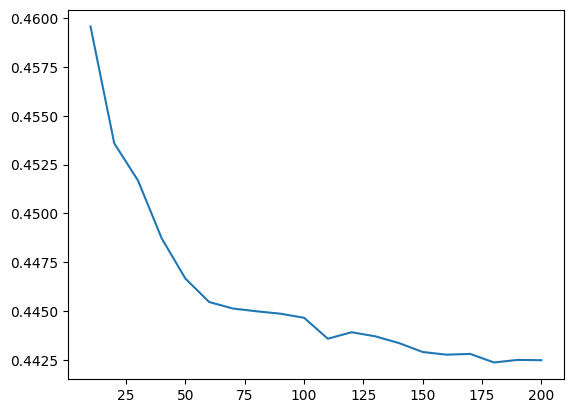

In [32]:
plt.plot(df_scores.n_estimators, df_scores.rmse)

In [ ]:
df_scores.head()

### Question 3: After which value of n_estimators does RMSE stop improving? Consider 3 decimal places for calculating the answer.
#### Answer is 200

In [34]:
scores = []

for depth in [10, 15, 20, 25]:
    for n in range(10, 201, 10):
        rf = RandomForestRegressor(max_depth=depth, n_estimators=n, random_state=1)
        rf.fit(X_train, y_train)
    
        print(n)
        y_pred = rf.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
    
        scores.append((depth, n, rmse))

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200


In [35]:
columns = ['max_depth', 'n_estimators', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)

In [37]:
df_scores_pivot = df_scores.pivot(index='n_estimators', columns=['max_depth'], values=['rmse'])
df_scores_pivot.round(3)

rmse                     
max_depth        10     15     20     25
n_estimators                            
10            0.450  0.458  0.459  0.459
20            0.447  0.453  0.454  0.454
30            0.445  0.451  0.452  0.452
40            0.443  0.449  0.449  0.449
50            0.442  0.446  0.447  0.447
60            0.442  0.445  0.446  0.446
70            0.441  0.445  0.445  0.445
80            0.441  0.445  0.446  0.445
90            0.442  0.445  0.446  0.445
100           0.441  0.444  0.445  0.445
110           0.441  0.443  0.444  0.444
120           0.441  0.444  0.444  0.444
130           0.441  0.444  0.444  0.444
140           0.440  0.443  0.444  0.443
150           0.440  0.443  0.443  0.443
160           0.440  0.443  0.443  0.443
170           0.440  0.443  0.443  0.443
180           0.440  0.442  0.443  0.442
190           0.440  0.442  0.443  0.443
200           0.440  0.442  0.443  0.442

<Axes: xlabel='None-max_depth', ylabel='n_estimators'>

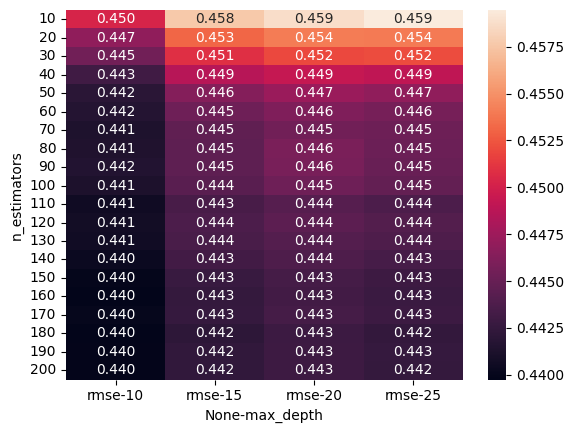

In [38]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

In [39]:
df_scores.groupby('max_depth')['rmse'].mean()

max_depth
10    0.441808
15    0.445417
20    0.446253
25    0.445910
Name: rmse, dtype: float64

### Question 4: What's the best max_depth, using the mean RMSE?
#### Answer is 10

In [40]:
# Training random forest regressor
rf = RandomForestRegressor(max_depth=20, n_estimators=10, random_state=1, n_jobs=-1)

In [43]:
rf.fit(X_train, y_train)

importances = rf.feature_importances_
print(importances)

[1.14797006e-02 3.57108549e-04 3.45384113e-04 3.27279191e-03
 3.25424323e-04 3.60383601e-04 1.59978977e-02 3.21230009e-03
 2.34334695e-03 1.63498954e-03 4.62246496e-04 5.18739639e-04
 5.39721689e-04 9.59149965e-01]


In [44]:
feature_names = dv.get_feature_names_out()

feat_imp = list(zip(feature_names, importances))

In [46]:
feat_imp_sorted = sorted(feat_imp, key=lambda x: x[1], reverse=True)

In [47]:
feat_imp_sorted

[('vehicle_weight', np.float64(0.9591499647407432)),
 ('horsepower', np.float64(0.015997897714266237)),
 ('acceleration', np.float64(0.01147970063142938)),
 ('engine_displacement', np.float64(0.0032727919136094864)),
 ('model_year', np.float64(0.003212300094794675)),
 ('num_cylinders', np.float64(0.0023433469524512048)),
 ('num_doors', np.float64(0.0016349895439306998)),
 ('origin=usa', np.float64(0.0005397216891829147)),
 ('origin=europe', np.float64(0.000518739638586969)),
 ('origin=asia', np.float64(0.0004622464955097423)),
 ('fuel_type=gasoline', np.float64(0.00036038360069172865)),
 ('drivetrain=all-wheel_drive', np.float64(0.0003571085493021933)),
 ('drivetrain=front-wheel_drive', np.float64(0.00034538411263183535)),
 ('fuel_type=diesel', np.float64(0.000325424322869738))]

In [51]:
for name, score in feat_imp_sorted:
    print(f"{name}: {score:.4f}")

vehicle_weight: 0.9591
horsepower: 0.0160
acceleration: 0.0115
engine_displacement: 0.0033
model_year: 0.0032
num_cylinders: 0.0023
num_doors: 0.0016
origin=usa: 0.0005
origin=europe: 0.0005
origin=asia: 0.0005
fuel_type=gasoline: 0.0004
drivetrain=all-wheel_drive: 0.0004
drivetrain=front-wheel_drive: 0.0003
fuel_type=diesel: 0.0003


### Question 5: What's the most important feature (among these 4)?
#### Answer: vehicle_weight

## Gradient boosting and XGBoost

In [21]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [22]:
import xgboost as xgb

In [23]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)


In [24]:
%%capture output

xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

In [26]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [27]:
model = xgb.train(xgb_params, dtrain, num_boost_round=100, evals=watchlist)

[0]	train-rmse:1.81393	val-rmse:1.85444
[1]	train-rmse:1.31919	val-rmse:1.35353
[2]	train-rmse:0.98120	val-rmse:1.01316
[3]	train-rmse:0.75443	val-rmse:0.78667
[4]	train-rmse:0.60680	val-rmse:0.64318
[5]	train-rmse:0.51381	val-rmse:0.55664
[6]	train-rmse:0.45470	val-rmse:0.50321
[7]	train-rmse:0.41881	val-rmse:0.47254
[8]	train-rmse:0.39534	val-rmse:0.45509
[9]	train-rmse:0.38038	val-rmse:0.44564
[10]	train-rmse:0.37115	val-rmse:0.43896
[11]	train-rmse:0.36361	val-rmse:0.43594
[12]	train-rmse:0.35850	val-rmse:0.43558
[13]	train-rmse:0.35365	val-rmse:0.43394
[14]	train-rmse:0.35025	val-rmse:0.43349
[15]	train-rmse:0.34666	val-rmse:0.43362
[16]	train-rmse:0.34459	val-rmse:0.43378
[17]	train-rmse:0.34128	val-rmse:0.43405
[18]	train-rmse:0.33822	val-rmse:0.43391
[19]	train-rmse:0.33709	val-rmse:0.43374
[20]	train-rmse:0.33553	val-rmse:0.43376
[21]	train-rmse:0.33243	val-rmse:0.43453
[22]	train-rmse:0.33031	val-rmse:0.43510
[23]	train-rmse:0.32815	val-rmse:0.43601
[24]	train-rmse:0.32670	va

In [28]:
s = output.stdout

In [29]:
print(s[:50])

In [30]:
y_pred = model.predict(dval)

In [33]:
root_mean_squared_error(y_val, y_pred)

0.45017755678087246

In [36]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [37]:
%%capture output

xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100, verbose_eval=5, evals=watchlist)

In [38]:
y_pred = model.predict(dval)

In [39]:
root_mean_squared_error(y_val, y_pred)

0.42622800553359225

### Question 6: Which eta leads to the best RMSE score on the validation dataset?
#### Answer is 0.1